# Notebook angle estimation machine learning part
This notebook contains the code that is used to train the model for predicting the best angle at which the angiography should be taken 

In [1]:
import pandas as pd
import torch 
import numpy as np
import torch.nn as nn
from torchsummary import summary
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from datetime import datetime

from torchvision.io import read_image
from torchvision.transforms.functional import to_tensor


DATA_PATH = "dataset/" #Do not change folder structure that was created by Kasper
# dataset/
#   DRR_images/
#       [n].png
#   excel/
#       *.xlsx 


In [4]:
torch.__version__

'2.6.0+cu126'

In [5]:
torch.cuda.is_available()

True

## Loading labels

In [2]:
labels = pd.read_excel(DATA_PATH+"excel/all_DRR_scores.xlsx")
labels['fullpath'] = DATA_PATH+"DRR_images/"+labels['DRR filename']+".png"
#labels.iloc[0]['fullpath']
labels

,DRR filename,aneurysm score,neck score,score,fullpath
0,C0001_X0_Y0,12.272727,1.783784,14.056511,dataset/DRR_images/C0001_X0_Y0.png
1,C0001_X10_Y0,7.358974,1.584906,8.943880,dataset/DRR_images/C0001_X10_Y0.png
2,C0001_X20_Y0,5.538462,1.921569,7.460030,dataset/DRR_images/C0001_X20_Y0.png
3,C0001_X30_Y0,5.309091,2.074074,7.383165,dataset/DRR_images/C0001_X30_Y0.png
4,C0001_X40_Y0,4.949153,1.689189,6.638342,dataset/DRR_images/C0001_X40_Y0.png
...,...,...,...,...,...
6835,C0074_X310_Y180,2.008721,2.130435,4.139156,dataset/DRR_images/C0074_X310_Y180.png
6836,C0074_X320_Y180,1.817175,1.709091,3.526265,dataset/DRR_images/C0074_X320_Y180.png
6837,C0074_X330_Y180,1.527578,2.289474,3.817052,dataset/DRR_images/C0074_X330_Y180.png
6838,C0074_X340_Y180,3.066038,2.050000,5.116038,dataset/DRR_images/C0074_X340_Y180.png


### DataLoader

In [3]:
class CustomImageDataset(torch.utils.data.Dataset):
    def __init__(self, data):
        self.img_labels = data
        self.img_labels['fullpath'] = DATA_PATH+"DRR_images/"+self.img_labels['DRR filename']+".png"
        self.img_dir = DATA_PATH+"DRR_images"
        self.transform = None
        self.target_transform = None
    
    def __len__(self):
        return len(self.img_labels)
    
    def __getitem__(self, idx):
        image = read_image(self.img_labels.iloc[idx]["fullpath"])
        image = image.type(torch.FloatTensor)
        label = self.img_labels.iloc[idx]["score"]
        return image, label
    
train, val = train_test_split(labels)

train_dataloader = torch.utils.data.DataLoader(CustomImageDataset(train), batch_size=64, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(CustomImageDataset(val), batch_size=64, shuffle=True)


Feature batch shape: torch.Size([64, 1, 256, 256])
Feature batch type: torch.FloatTensor
Labels batch shape: torch.Size([64])


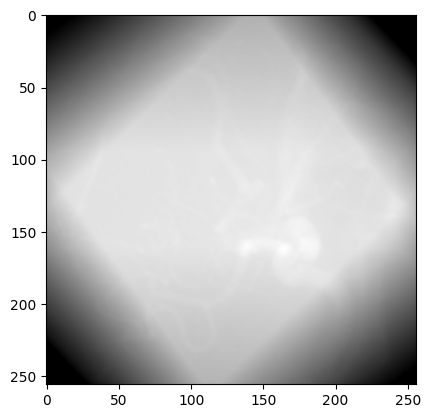

Label: 51.26190476190476


In [4]:
train, label = next(iter(train_dataloader))
print(f"Feature batch shape: {train.size()}")
print(f"Feature batch type: {train.type()}")
print(f"Labels batch shape: {label.size()}")
img = train[31].squeeze()
label = label[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")

### Model

In [55]:
import torch.nn.functional as F
class Block(nn.Module):
    def __init__(self):
        super(Block, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, 3, 1, 1)  # In: (1, 256, 256), Out: (32, 256, 256)
        self.pool1 = nn.MaxPool2d(2,2)         # In: (32, 256, 256), Out: (32, 64, 64)
        self.conv2 = nn.Conv2d(4, 16, 3, 1, 1) # In: (32, 64, 64), Out: (64, 62, 62)
        self.pool2 = nn.MaxPool2d(2,2)         # In: (64, 62, 62), Out: (64, 15, 15)
        self.flatten = nn.Flatten()
        self.ln1 = nn.Linear(16*64*64, 64)  # Aangepast naar de juiste grootte van de tensor
        self.relu = nn.ReLU()
        self.ln2 = nn.Linear(64,1)
        self.bn1 = nn.BatchNorm2d(4)
        self.bn2 = nn.BatchNorm2d(16)


    def forward(self, x):
        x = self.conv1(x)  # Convolution layer 1
        x = self.bn1(x)
        x = self.pool1(x)  # Pooling layer 1
        x = self.conv2(x)  # Convolution layer 2
        x = self.bn2(x)
        x = self.pool2(x)  # Pooling layer 2
        x = self.flatten(x)  # Flatten the tensor
        x = self.ln1(x)  # Fully connected layer
        x = self.ln2(x)
        return x


In [56]:
device = torch.device("cuda")
model = Block().to(device)

summary(model, torch.Size([1,256,256]), 64)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [64, 4, 256, 256]              40
       BatchNorm2d-2          [64, 4, 256, 256]               8
         MaxPool2d-3          [64, 4, 128, 128]               0
            Conv2d-4         [64, 16, 128, 128]             592
       BatchNorm2d-5         [64, 16, 128, 128]              32
         MaxPool2d-6           [64, 16, 64, 64]               0
           Flatten-7                [64, 65536]               0
            Linear-8                   [64, 64]       4,194,368
            Linear-9                    [64, 1]              65
Total params: 4,195,105
Trainable params: 4,195,105
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 16.00
Forward/backward pass size (MB): 608.03
Params size (MB): 16.00
Estimated Total Size (MB): 640.03
---------------------------------

In [57]:
output = model(train.to(device))
output

tensor([[ 0.3865],
        [ 0.3966],
        [ 0.1656],
        [ 0.2720],
        [ 0.1199],
        [ 0.2825],
        [ 0.3191],
        [ 0.1526],
        [ 0.3758],
        [ 0.3595],
        [ 0.2653],
        [-0.0058],
        [ 0.2686],
        [ 0.2749],
        [ 0.2435],
        [ 0.2511],
        [ 0.2709],
        [ 0.2357],
        [ 0.2668],
        [ 0.2693],
        [ 0.2235],
        [ 0.1665],
        [ 0.2306],
        [ 0.3880],
        [ 0.2711],
        [ 0.2901],
        [ 0.1956],
        [ 0.0704],
        [ 0.2324],
        [ 0.4038],
        [ 0.2956],
        [ 0.3606],
        [ 0.2356],
        [ 0.3724],
        [ 0.3382],
        [ 0.1478],
        [ 0.2159],
        [ 0.3512],
        [ 0.1371],
        [ 0.2519],
        [-0.0059],
        [ 0.3290],
        [ 0.3183],
        [ 0.2197],
        [ 0.2310],
        [ 0.3379],
        [ 0.2183],
        [ 0.1954],
        [ 0.2956],
        [ 0.4904],
        [ 0.2171],
        [ 0.2731],
        [ 0.

### Loss function

In [58]:
loss_fn = nn.MSELoss()
loss_fn.to(device=device)

MSELoss()

### Optimizer

In [59]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


### Training

In [60]:
def train_one_epoch(epoch_index):
    running_loss = 0.
    last_loss = 0.

    # Here, we use enumerate(training_loader) instead of
    # iter(training_loader) so that we can track the batch
    # index and do some intra-epoch reporting
    for i, data in enumerate(train_dataloader):
        # Every data instance is an input + label pair
        inputs, labels = data
        

        # Zero your gradients for every batch!
        optimizer.zero_grad()

        # Make predictions for this batch
        outputs = model(inputs.to(device))

        # Compute the loss and its gradients
        loss = loss_fn(outputs, labels.to(device).float())
        loss.backward()

        # Adjust learning weights
        optimizer.step()

        # Gather data and report
        running_loss += loss.item()
        if i % 10 == 9:
            last_loss = running_loss / 10 # loss per batch
            print('  batch {} loss: {}'.format(i + 1, last_loss))
            tb_x = epoch_index * len(train_dataloader) + i + 1
            running_loss = 0.

    return last_loss

In [61]:
# Initializing in a separate cell so we can easily add more epochs to the same run
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
#writer = SummaryWriter('runs/fashion_trainer_{}'.format(timestamp))
epoch_number = 0

EPOCHS = 100

best_vloss = 1_000_000.

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_loss = train_one_epoch(epoch_number)


    running_vloss = 0.0
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_dataloader):
            vinputs, vlabels = vdata
            voutputs = model(vinputs.to(device))
            vloss = loss_fn(voutputs, vlabels.to(device).float())
            running_vloss += vloss

    avg_vloss = running_vloss / (i + 1)
    print('LOSS train {} valid {}'.format(avg_loss, avg_vloss))


    # Track best performance, and save the model's state
    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        model_path = 'model_{}_{}'.format(timestamp, epoch_number)
        torch.save(model.state_dict(), model_path)

    epoch_number += 1
model.train(False)

EPOCH 1:
  batch 10 loss: 7665.320642089844
  batch 20 loss: 2495.138537597656
  batch 30 loss: 940.0134498596192
  batch 40 loss: 726.0649230957031
  batch 50 loss: 945.7728698730468
  batch 60 loss: 1618.5293479919433
  batch 70 loss: 807.8527618408203
  batch 80 loss: 2169.7885406494142
LOSS train 2169.7885406494142 valid 1026.8587646484375
EPOCH 2:
  batch 10 loss: 1039.9754486083984
  batch 20 loss: 909.1966335296631
  batch 30 loss: 812.9774871826172
  batch 40 loss: 2887.715689086914
  batch 50 loss: 1113.3593490600585
  batch 60 loss: 988.3377075195312
  batch 70 loss: 847.1360961914063
  batch 80 loss: 765.9348083496094
LOSS train 765.9348083496094 valid 918.82958984375
EPOCH 3:
  batch 10 loss: 893.8104042053222
  batch 20 loss: 1004.5199119567872
  batch 30 loss: 597.7641998291016
  batch 40 loss: 789.1608184814453
  batch 50 loss: 881.6598831176758
  batch 60 loss: 750.6285400390625
  batch 70 loss: 3006.0213134765627
  batch 80 loss: 973.3829925537109
LOSS train 973.382992

Block(
  (conv1): Conv2d(1, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(4, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (ln1): Linear(in_features=65536, out_features=64, bias=True)
  (relu): ReLU()
  (ln2): Linear(in_features=64, out_features=1, bias=True)
  (bn1): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)

In [62]:
torch.save(model.state_dict(), "mymodel.pth")

In [42]:
torch.cuda.empty_cache()
del model
del loss_fn

print(torch.cuda.memory_allocated())
print(torch.cuda.memory_reserved())

999688192
1042284544


In [63]:
device2 = torch.device("cuda")
mymodel = Block()
mymodel.load_state_dict(torch.load("mymodel.pth", weights_only=True))
mymodel.eval()
mymodel.to(device2)

Block(
  (conv1): Conv2d(1, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(4, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (ln1): Linear(in_features=65536, out_features=64, bias=True)
  (relu): ReLU()
  (ln2): Linear(in_features=64, out_features=1, bias=True)
  (bn1): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)

In [64]:
test, label = next(iter(val_dataloader))


In [65]:
print(test.size())

torch.Size([64, 1, 256, 256])


In [66]:

with torch.no_grad():
    estimate = mymodel(test.to(device2)).detach().cpu().numpy()


In [67]:
estimate[5][0]

np.float32(18.581886)

[Text(0.5, 1.0, 'ML Performance'),
 Text(0.5, 0, 'Real'),
 Text(0, 0.5, 'Estimated')]

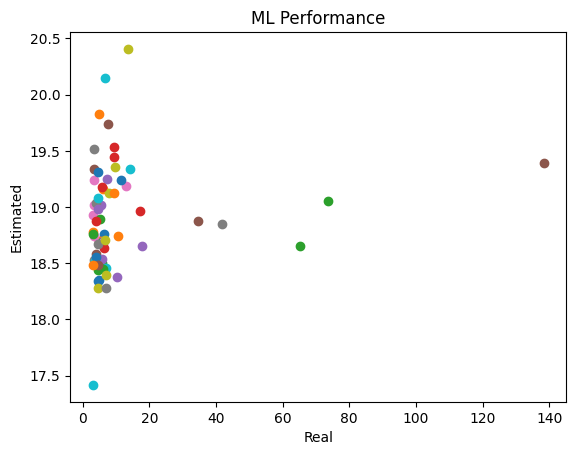

In [68]:

result = []
for i,l in enumerate(label):
    plt.scatter(float(l), float(estimate[i][0]))
    result.append((float(l), float(estimate[i][0])))

plt.gca().update(dict(title='ML Performance', xlabel="Real", ylabel="Estimated"))



    

In [69]:
result

[(6.242252291575731, 18.75619888305664),
 (6.121367521367521, 19.162195205688477),
 (5.85, 18.4998722076416),
 (4.854727398205659, 18.70052719116211),
 (17.86166007905138, 18.651548385620117),
 (3.805911144578313, 18.581886291503906),
 (3.17584014979797, 18.929317474365234),
 (3.412037037037037, 19.51904296875),
 (7.736111111111111, 19.123573303222656),
 (3.019224538287072, 17.416786193847656),
 (4.830721003134796, 18.354101181030273),
 (5.344477611940299, 18.69811248779297),
 (4.56989247311828, 18.439373016357422),
 (9.267857142857142, 19.447616577148438),
 (5.81904761904762, 18.53609848022461),
 (7.649296790479625, 19.737077713012695),
 (3.466226622662266, 19.24437141418457),
 (41.90476190476191, 18.848539352416992),
 (13.51049475262369, 20.407211303710938),
 (6.833333333333333, 18.457603454589844),
 (4.626733921815889, 18.34166717529297),
 (4.874603174603175, 19.827014923095703),
 (65.25, 18.654354095458984),
 (17.05555555555556, 18.964702606201172),
 (10.13265306122449, 18.37854003